In [1]:
import pandas as pd

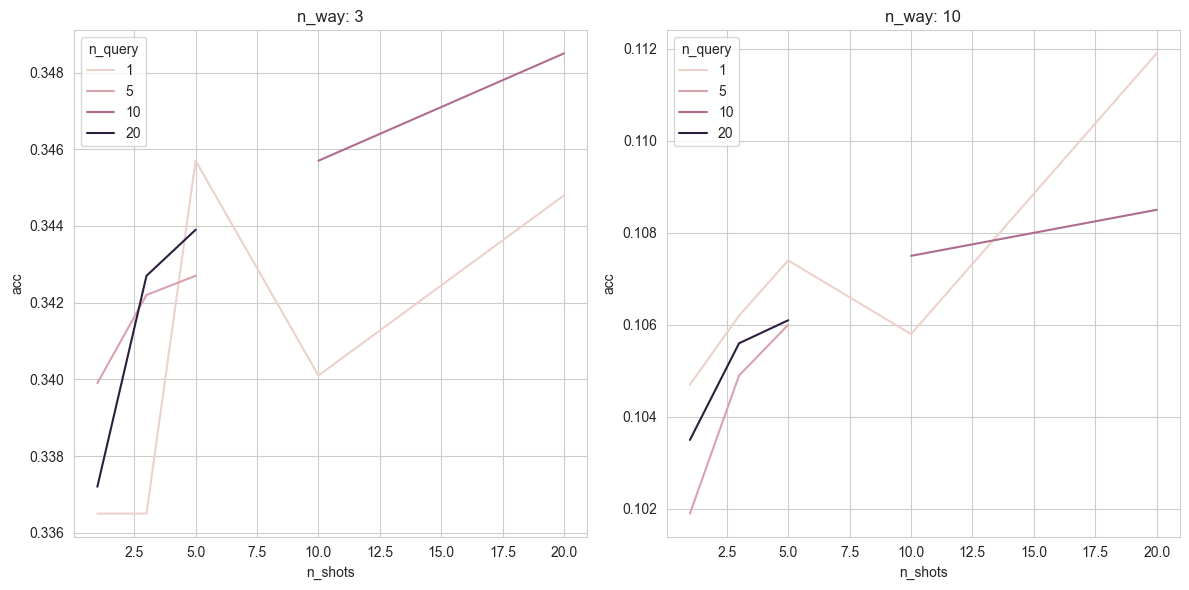

In [46]:
a = '''n_way: 3
n_shots: 1
n_query: 1
acc=0.3365 ± 0.1193 loss=3.5870

n_way: 3
n_shots: 1
n_query: 5
acc=0.3399 ± 0.0526 loss=3.6068

n_way: 3
n_shots: 1
n_query: 20
acc=0.3372 ± 0.0273 loss=3.6455

n_way: 3
n_shots: 3
n_query: 1
acc=0.3365 ± 0.1184 loss=2.6146

n_way: 3
n_shots: 3
n_query: 5
acc=0.3422 ± 0.0532 loss=2.5877

n_way: 3
n_shots: 3
n_query: 20
acc=0.3427 ± 0.0299 loss=2.5672

n_way: 3
n_shots: 5
n_query: 1
acc=0.3457 ± 0.1238 loss=2.0614

n_way: 3
n_shots: 5
n_query: 5
acc=0.3427 ± 0.0545 loss=2.1122

n_way: 3
n_shots: 5
n_query: 20
acc=0.3439 ± 0.0286 loss=2.1300

n_way: 10
n_shots: 1
n_query: 1
acc=0.1047 ± 0.0420 loss=6.3781

n_way: 10
n_shots: 1
n_query: 5
acc=0.1019 ± 0.0185 loss=6.4753

n_way: 10
n_shots: 1
n_query: 20
acc=0.1035 ± 0.0100 loss=6.4957

n_way: 10
n_shots: 3
n_query: 1
acc=0.1062 ± 0.0440 loss=4.9398

n_way: 10
n_shots: 3
n_query: 5
acc=0.1049 ± 0.0185 loss=4.8486

n_way: 10
n_shots: 3
n_query: 20
acc=0.1056 ± 0.0100 loss=4.6929

n_way: 10
n_shots: 5
n_query: 1
acc=0.1074 ± 0.0428 loss=4.0645

n_way: 10
n_shots: 5
n_query: 5
acc=0.1060 ± 0.0180 loss=3.9552

n_way: 10
n_shots: 5
n_query: 20
acc=0.1061 ± 0.0104 loss=3.8499

n_way: 3
n_shots: 10
n_query: 1
acc=0.3401 ± 0.1150 loss=1.5795

n_way: 3
n_shots: 10
n_query: 10
acc=0.3457 ± 0.0412 loss=1.6197

n_way: 3
n_shots: 20
n_query: 1
acc=0.3448 ± 0.1102 loss=1.3091

n_way: 3
n_shots: 20
n_query: 10
acc=0.3485 ± 0.0364 loss=1.3219

n_way: 10
n_shots: 10
n_query: 1
acc=0.1058 ± 0.0395 loss=3.1494

n_way: 10
n_shots: 10
n_query: 10
acc=0.1075 ± 0.0132 loss=3.0157

n_way: 10
n_shots: 20
n_query: 1
acc=0.1119 ± 0.0400 loss=2.608

n_way: 10
n_shots: 20
n_query: 10
acc=0.1085 ± 0.0127 loss=2.5433'''

df = pd.DataFrame([b.split('\n') for b in a.split('\n\n')])
df[0] = df[0].str.extract(r'n_way: (\d+)').astype(int)
df[1] = df[1].str.extract(r'n_shots: (\d+)').astype(int)
df[2] = df[2].str.extract(r'n_query: (\d+)').astype(int)
acc = df[3].str.extractall(r'acc=(\d+\.\d+)').reset_index(level=1, drop=True)
std = df[3].str.extractall(r'± (\d+\.\d+)').reset_index(level=1, drop=True)
loss = df[3].str.extractall(r'loss=(\d+\.\d+)').reset_index(level=1, drop=True)
df[4] = acc.astype(float)
df[5] = std.astype(float)
df[6] = loss.astype(float)
df.columns = ['n_way', 'n_shots', 'n_query', 'acc_std_loss', 'acc', 'std', 'loss']
del df['acc_std_loss']


#for each nway, plot nshot vs acc for each nquery
import matplotlib.pyplot as plt
import seaborn as sns

# set fig grid
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, n_way in enumerate(df['n_way'].unique()):
    sns.lineplot(data=df[df['n_way'] == n_way], x='n_shots', y='acc', hue='n_query', ax=axes[i])
    axes[i].set_title(f'n_way: {n_way}')
    axes[i].set_xlabel('n_shots')
    axes[i].set_ylabel('acc')
    axes[i].legend(title='n_query')
plt.tight_layout()
plt.show()

In [ ]:
import wandb
import pandas as pd

api = wandb.Api()
runs = api.runs("eibl-usc/graph-clip", filters={"config.params.prefix": {"$regex": "eval_retweet"}})

rows = []
for run in runs:
    row = {
        "n_way": run.config["params"]["n_way"],
        "n_shots": run.config["params"]["n_shots"],
        "n_query": run.config["params"]["n_query"],
        "acc": run.summary.get("start_test_acc"),
        "std": run.summary.get("start_test_acc_std"),
        # "loss": run.summary.get("start_test_loss"),
        'start_time': run.created_at
    }
    rows.append(row)
df = pd.DataFrame(rows)

In [141]:
d = df.sort_values('start_time', ascending=False)[:12]

print(d)

    n_way  n_shots  n_query       acc       std            start_time
40     10       20       10  0.657264  0.044140  2026-03-07T23:44:15Z
39     10       20        1  0.591400  0.071232  2026-03-07T23:40:18Z
38     10        5       10  0.576152  0.050729  2026-03-07T23:37:40Z
37     10        5        1  0.505760  0.068191  2026-03-07T23:36:32Z
36     10        1       10  0.455556  0.054353  2026-03-07T23:34:34Z
35     10        1        1  0.446560  0.075832  2026-03-07T23:34:04Z
34      3       20       10  0.881667  0.060478  2026-03-07T23:31:59Z
33      3       20        1  0.841067  0.098805  2026-03-07T23:30:37Z
32      3        5       10  0.809707  0.072567  2026-03-07T23:29:39Z
31      3        5        1  0.765200  0.112537  2026-03-07T23:29:11Z
30      3        1       10  0.713920  0.087536  2026-03-07T23:28:24Z
29      3        1        1  0.711333  0.116792  2026-03-07T23:28:06Z


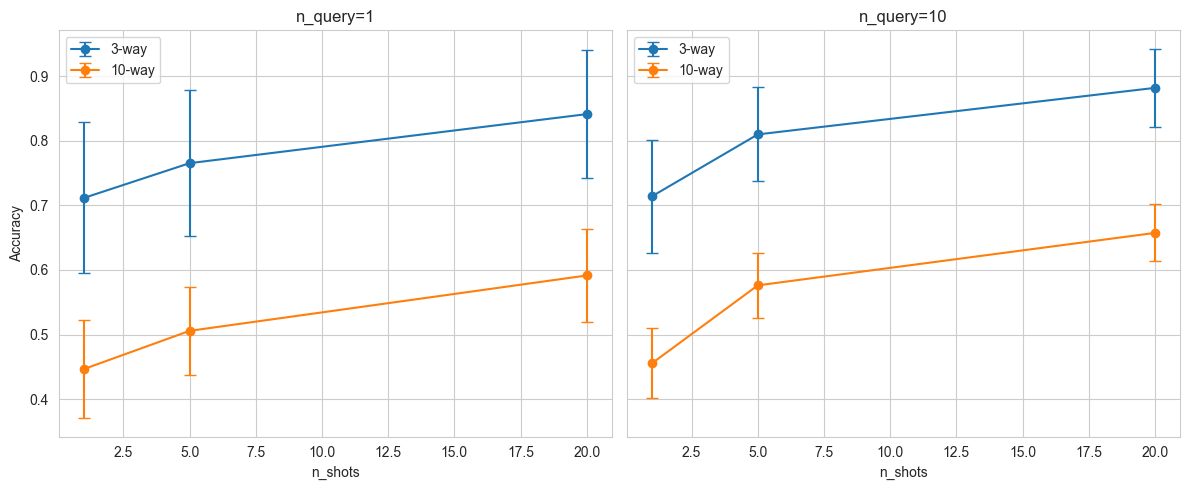

In [146]:
fig, axes = plt.subplots(1, d["n_query"].nunique(), figsize=(12, 5), sharey=True)

for ax, (n_query, qdf) in zip(axes, d.groupby("n_query")):
    for n_way, group in qdf.groupby("n_way"):
        group_sorted = group.sort_values("n_shots")
        ax.errorbar(group_sorted["n_shots"], group_sorted["acc"], yerr=group_sorted["std"],
                    marker="o", label=f"{n_way}-way", capsize=4)
    ax.set_xlabel("n_shots")
    ax.set_title(f"n_query={n_query}")
    ax.legend()

axes[0].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Define the path
path = 'armenia_202012_tweets_io.pkl.gz'

# Load the data
df = pd.read_pickle(path)

# Preview the first few rows
df.head()

,tweetid,userid,user_display_name,user_screen_name,user_reported_location,user_profile_description,user_profile_url,follower_count,following_count,account_creation_date,...,retweet_tweetid,latitude,longitude,quote_count,reply_count,like_count,retweet_count,hashtags,urls,user_mentions
0,1331706590525874184,1330897620257136640,Haqqin.az,Haqqinz,Azerbaijan,https://t.co/7q3bPlI5Ne является независимым и...,https://t.co/TY3gz33nIF,0,0,2020-11-23,...,NaN,absent,absent,0,0,0,0,"[haqqinaz, haqqin, haqqinz]",[https://haqqin.az/news/194712],[]
1,1100358276435398656,1098549517299957761,Adem Elekberov,AdemElekberov,Azerbaijan,I’ve learned I don’t know anything. Have also...,NaN,145,530,2019-02-21,...,NaN,absent,absent,0,0,0,0,"[Azerbaijan, shareforkhojaly, justiceforkhojaly]",[],[]
2,1100389340914569216,1098613626204753920,Cebrayil Babayev,CebrayilBabaye1,"Agri, Turkey",Love the life to its fullest\n#Shareforkhojaly...,NaN,146,423,2019-02-21,...,NaN,absent,absent,1,0,0,0,"[shareforkhojaly, justiceforkhojaly]",[],[]
3,724982683118358528,719246221509005313,Zakir Həsənov,zakir_hasanov,Azerbaijan,Lieutenant General is an Azerbaijani politicia...,https://t.co/06ojhMm2e6,112,15,2016-04-10,...,NaN,absent,absent,0,0,0,0,[],[http://www.unaoc.org/wp-content/uploads/20160...,[]
4,728142042765742080,719246221509005313,Zakir Həsənov,zakir_hasanov,Azerbaijan,Lieutenant General is an Azerbaijani politicia...,https://t.co/06ojhMm2e6,112,15,2016-04-10,...,NaN,absent,absent,0,0,0,0,[Azerbaijan],[http://bit.ly/24tbEqN],[]


In [247]:
import wandb
import pandas as pd

api = wandb.Api()
runs = api.runs("eibl-usc/graph-clip", filters={"config.params.prefix": {"$regex": "eval_(pseudo|finetune)"}})

rows = []
for run in runs:
    row = {
        "n_way": run.config["params"]["n_way"],
        "n_shots": run.config["params"]["n_shots"],
        "n_query": run.config["params"]["n_query"],
        "acc": run.summary.get("start_test_acc"),
        "std": run.summary.get("start_test_acc_std"),
        # "loss": run.summary.get("start_test_loss"),
        'start_time': run.created_at,
        'config': run.config,
        'summary': run.summary,
        'name': run.name
    }
    rows.append(row)
df = pd.DataFrame(rows)

In [248]:
df = df.sort_values('start_time', ascending=False)

In [249]:
df = df[:15]
df["trained_on"] = df.name.str.extract('(scratch|finetune)').fillna('pretrain')

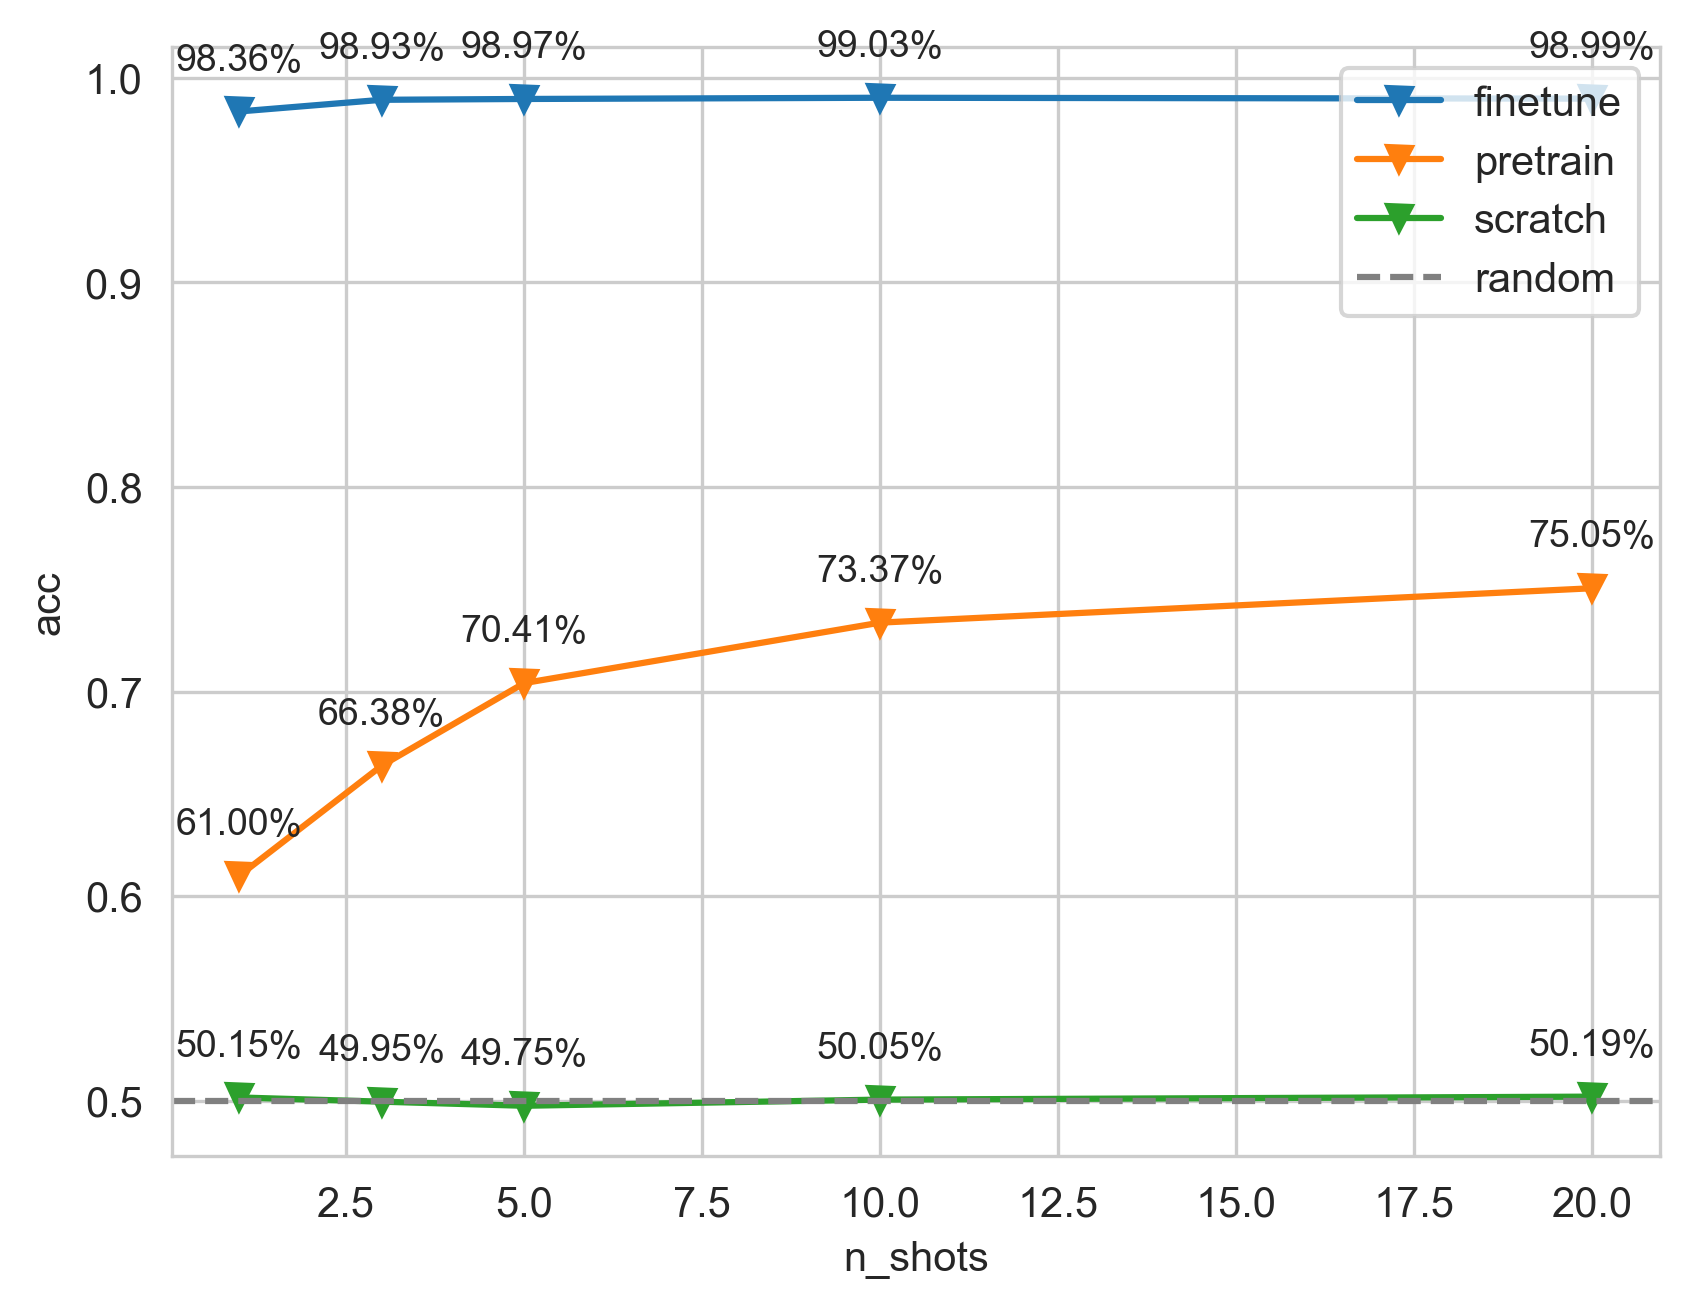

In [261]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Store the pivoted dataframe to easily iterate over it for labels
df_pivot = df.pivot(index='n_shots', columns='trained_on', values='acc')
df_pivot.plot(ax=ax, marker='v')

# Add labels with formatting xx.x%
for col in df_pivot.columns:
    for x, y in zip(df_pivot.index, df_pivot[col]):
        # y*100 converts decimal to percentage; :.1f formats to 1 decimal place
        label = f"{y*100:.2f}%"
        
        ax.annotate(label, 
                    (x, y), 
                    textcoords="offset points", # position relative to the point
                    xytext=(0, 10),             # 10 points vertical offset
                    ha='center',                # horizontal alignment
                    fontsize=9)

ax.set_xlabel('n_shots')
ax.set_ylabel('acc')
ax.axhline(0.5, linestyle='--', color='gray', label='random')


plt.rcParams['figure.dpi'] = 300

# Ensure legend handles both the lines and the 'random' line
ax.legend() 
plt.show()